<a href="https://colab.research.google.com/github/Sachin0552451/-OIBSIP/blob/main/SuperStore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Explorartariy Data Analysis on Super Store sales data.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [ ]:
df = pd.read_csv('/content/gdrive/My Drive/OASIS projects/super store EDA project/Superstore dataset.csv', encoding="latin1")

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.shape

(9994, 21)

In [ ]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [ ]:
df.columns.tolist()
df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,object
Ship Date,object
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [ ]:
df.info()
df.isnull().sum().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Category"].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [ ]:
df["Segment"].unique()


array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [ ]:
df["Region"].unique()

array(['South', 'West', 'Central', 'East'], dtype=object)

In [ ]:
df["Customer ID"].nunique()

793

In [ ]:
df["Product ID"].nunique()

1862

In [ ]:
df["Order ID"].nunique()

5009

In [ ]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [ ]:
summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Unique Values": df.nunique().values
})

summary

,Column,Data Type,Missing Values,Unique Values
0,Row ID,int64,0,9994
1,Order ID,object,0,5009
2,Order Date,object,0,1237
3,Ship Date,object,0,1334
4,Ship Mode,object,0,4
5,Customer ID,object,0,793
6,Customer Name,object,0,793
7,Segment,object,0,3
8,Country,object,0,1
9,City,object,0,531


# Observations

- The dataset contains 9,994 records and 21 columns.
- The dataset contains information about orders, customers, products, categories, regions, sales, quantity, discount, and profit.
- There are no missing values in any of the 21 columns.
- There are no completely duplicated records.
- The dataset contains both categorical and numerical variables suitable for exploratory analysis.
- The `Order Date` and `Ship Date` columns are currently stored as text and will need to be converted to datetime format before performing time-series analysis.
- The dataset does not contain customer age or gender information. Therefore, age-group and gender analysis cannot be performed directly. Customer segmentation using the available `Segment` variable will be used instead.'''

In [ ]:
# Data cleaning and preparation
df[["Order Date", "Ship Date"]].dtypes

,0
Order Date,object
Ship Date,object


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date']  )
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [ ]:
#this is for checking that conversion is correct or not
print("Missing Order Dates:", df["Order Date"].isna().sum())
print("Missing Ship Dates:", df["Ship Date"].isna().sum())

Missing Order Dates: 0
Missing Ship Dates: 0


In [ ]:
print("Order Date Range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date Range:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

Order Date Range:
2014-01-03 00:00:00 to 2017-12-30 00:00:00

Ship Date Range:
2014-01-07 00:00:00 to 2018-01-05 00:00:00


In [ ]:
#we know that shipping date is lesser than order date , so we check is there any invalid ship dates or not
invalid_ship_dates = df["Ship Date"] < df["Order Date"]

invalid_ship_dates.sum()

np.int64(0)

In [ ]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [ ]:
df['Shipping Days'].describe()
df["Shipping Days"].value_counts().sort_index()

,count
Shipping Days,
0,519
1,369
2,1334
3,1005
4,2774
5,2169
6,1203
7,621


In [ ]:
numeric_columns = df.select_dtypes(include=np.number).columns

numeric_columns

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit',
       'Shipping Days'],
      dtype='object')

In [ ]:
#check sales value
print("Minimum Sales:", df["Sales"].min())
print("Maximum Sales:", df["Sales"].max())
print("Negative Sales:", (df["Sales"] < 0).sum())
print("Zero Sales:", (df["Sales"] == 0).sum())

Minimum Sales: 0.444
Maximum Sales: 22638.48
Negative Sales: 0
Zero Sales: 0


In [ ]:
#check quantity
print("Minimum Quantity:", df["Quantity"].min())
print("Maximum Quantity:", df["Quantity"].max())
print("Non-positive Quantity:",(df["Quantity"] <= 0).sum())

Minimum Quantity: 1
Maximum Quantity: 14
Non-positive Quantity: 0


In [ ]:
#check discount
print("Minimum Discount:", df["Discount"].min())
print("Maximum Discount:", df["Discount"].max())
print("Invalid Discounts:",((df["Discount"] < 0) | (df["Discount"] > 1)).sum())

Minimum Discount: 0.0
Maximum Discount: 0.8
Invalid Discounts: 0


In [ ]:
print("Minimum Profit:", df["Profit"].min())
print("Maximum Profit:", df["Profit"].max())
print("Loss-making transactions:",
      (df["Profit"] < 0).sum())

Minimum Profit: -6599.978
Maximum Profit: 8399.976
Loss-making transactions: 1871


In [ ]:
df['Category'].value_counts()

,count
Category,
Office Supplies,6026
Furniture,2121
Technology,1847


In [ ]:
df['Segment'].value_counts()

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


In [ ]:
df['Region'].value_counts()

,count
Region,
West,3203
East,2848
Central,2323
South,1620


In [ ]:
df['Year'] = df['Order Date'].dt.year


In [ ]:
df['Month'] = df['Order Date'].dt.month

In [ ]:
df['Year'].unique()

array([2016, 2015, 2014, 2017], dtype=int32)

In [ ]:
df["Month Name"] = df["Order Date"].dt.month_name()

In [ ]:
df["Quarter"] = df["Order Date"].dt.quarter
df["Quarter"].unique()

array([4, 2, 3, 1], dtype=int32)

In [ ]:
df["Year-Month"] = df["Order Date"].dt.to_period("M")
df["Year-Month"].unique()

<PeriodArray>
['2016-11', '2016-06', '2015-10', '2014-06', '2017-04', '2016-12', '2015-11',
 '2014-11', '2014-05', '2014-08', '2017-07', '2015-09', '2016-01', '2017-10',
 '2015-12', '2017-09', '2016-07', '2016-03', '2014-10', '2015-04', '2014-12',
 '2016-09', '2017-12', '2017-11', '2017-05', '2016-04', '2015-01', '2017-06',
 '2016-08', '2015-03', '2014-09', '2017-02', '2016-10', '2015-05', '2014-03',
 '2016-05', '2015-02', '2015-08', '2015-07', '2014-07', '2015-06', '2014-04',
 '2017-03', '2017-08', '2017-01', '2014-02', '2014-01', '2016-02']
Length: 48, dtype: period[M]

In [ ]:
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df['Shipping Days'].head()

,Shipping Days
0,3
1,3
2,4
3,7
4,7


In [ ]:
#Creating a clean numeric column list
analysis_numric_cols = [
    'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Days'
]

In [ ]:
df.shape

(9994, 27)

In [ ]:
#final dataqulaity check before moving to EDA
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Invalid quantities:", (df["Quantity"] <= 0).sum())
print("Invalid discounts:",
      ((df["Discount"] < 0) | (df["Discount"] > 1)).sum())
print("Invalid shipping dates:",
      (df["Ship Date"] < df["Order Date"]).sum())

Rows: 9994
Columns: 27
Missing values: 0
Duplicate rows: 0
Invalid quantities: 0
Invalid discounts: 0
Invalid shipping dates: 0


Descriptive Statistics

In [ ]:
analysis_numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Days"
]

df[analysis_numeric_cols].head()

,Sales,Quantity,Discount,Profit,Shipping Days
0,261.9600,2,0.00,41.9136,3
1,731.9400,3,0.00,219.5820,3
2,14.6200,2,0.00,6.8714,4
3,957.5775,5,0.45,-383.0310,7
4,22.3680,2,0.20,2.5164,7


In [ ]:
descriptive_stats = pd.DataFrame({
    "Mean": df[analysis_numeric_cols].mean(),
    "Median": df[analysis_numeric_cols].median(),
    "Mode": df[analysis_numeric_cols].mode().iloc[0],
    "Standard Deviation": df[analysis_numeric_cols].std(),
    "Minimum": df[analysis_numeric_cols].min(),
    "Maximum": df[analysis_numeric_cols].max()
})

descriptive_stats.round(2)

,Mean,Median,Mode,Standard Deviation,Minimum,Maximum
Sales,229.86,54.49,12.96,623.25,0.44,22638.48
Quantity,3.79,3.00,3.00,2.23,1.00,14.00
Discount,0.16,0.20,0.00,0.21,0.00,0.80
Profit,28.66,8.67,0.00,234.26,-6599.98,8399.98
Shipping Days,3.96,4.00,4.00,1.75,0.00,7.00


In [ ]:
df["Profit"].describe()

,Profit
count,9994.000000
mean,28.656896
std,234.260108
min,-6599.978000
25%,1.728750
50%,8.666500
75%,29.364000
max,8399.976000


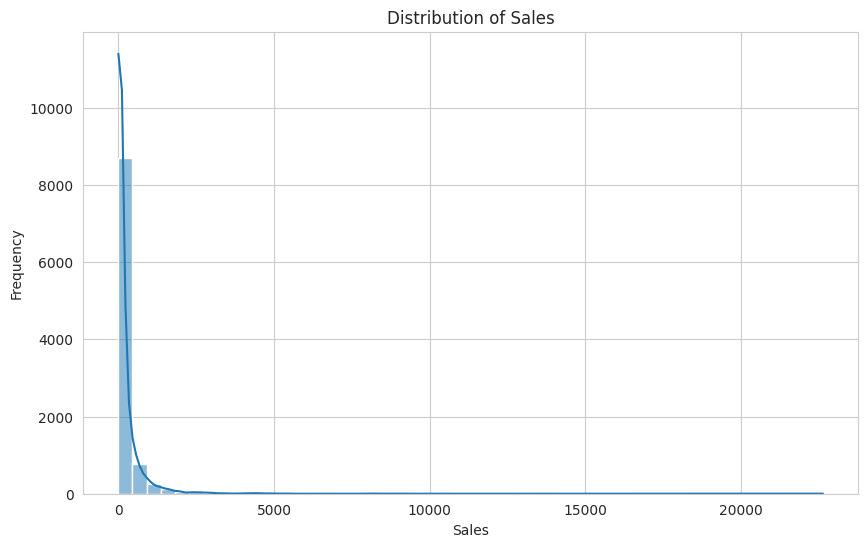

In [ ]:
#Distribution Visualization(Histogram)

#For Sales
plt.figure(figsize=(10, 6))

sns.histplot(df["Sales"], bins=50, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Observation — Sales Distribution

The sales distribution is concentrated around relatively lower transaction values, while a smaller number of transactions have substantially higher sales values. This indicates that the sales variable is positively skewed and that a small number of high-value transactions may influence the mean. Therefore, both mean and median should be considered when interpreting typical transaction value.

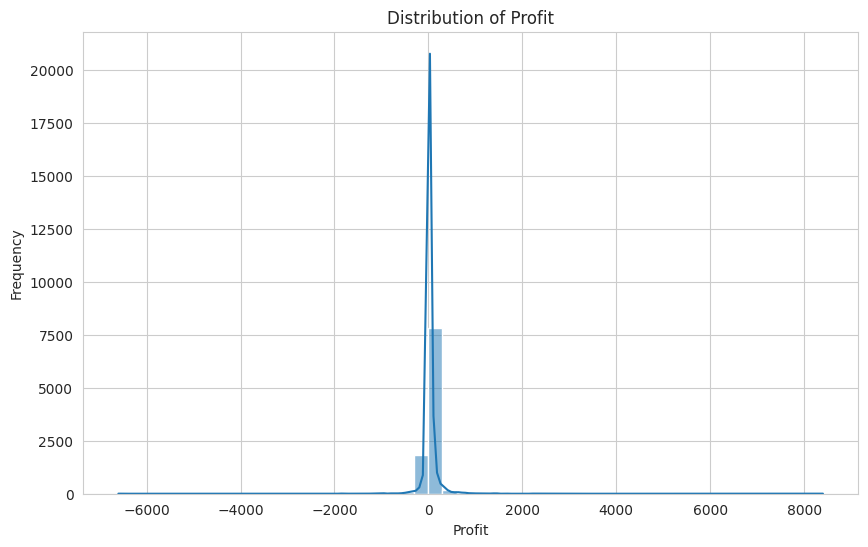

In [ ]:
#For Profit
plt.figure(figsize=(10, 6))

sns.histplot(df["Profit"], bins=50, kde=True)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

### Observation — Profit Distribution

The profit distribution shows that most transactions generate relatively small positive profits, while some transactions result in losses. The presence of negative profit values is important because it indicates that not every transaction is profitable. These loss-making transactions will be investigated further, particularly in relation to discounts, product categories, and customer segments.

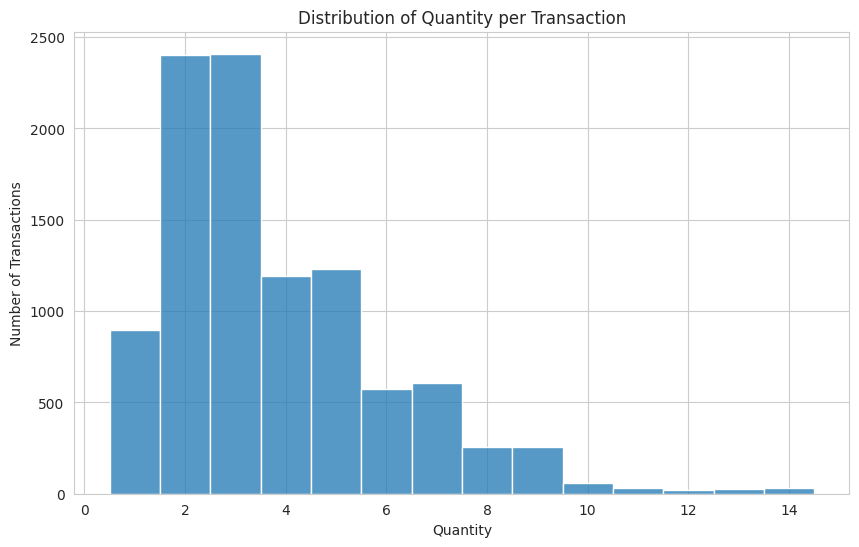

In [ ]:
#Quantity distribution
plt.figure(figsize=(10, 6))

sns.histplot(df["Quantity"], bins=14, discrete=True)

plt.title("Distribution of Quantity per Transaction")
plt.xlabel("Quantity")
plt.ylabel("Number of Transactions")

plt.show()

### Observation — Quantity Distribution

The quantity distribution indicates that most transactions involve a relatively small number of items, while larger quantities occur less frequently. This suggests that typical transactions are relatively small in terms of item count, with a limited number of bulk purchases.

In [ ]:
#Time-Series Analysis
yearly_sales = df.groupby("Year")["Sales"].sum()

yearly_sales

,Sales
Year,
2014,484247.4981
2015,470532.5090
2016,609205.5980
2017,733215.2552


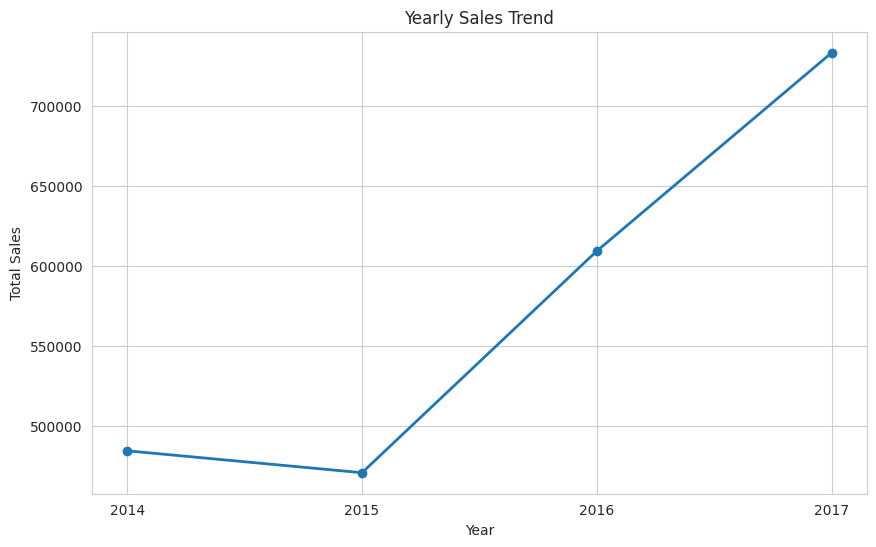

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_sales.index,
    yearly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.xticks(yearly_sales.index)

plt.show()

### Observation — Yearly Sales

The yearly sales trend provides an overall view of the company's sales performance between 2014 and 2017. Sales vary across the four years, allowing us to identify the strongest and weakest annual performance. The yearly comparison provides a high-level view, while monthly and quarterly analysis will help identify the specific periods responsible for these changes.

In [ ]:
#year-over-year growth
yearly_growth = yearly_sales.pct_change() * 100

yearly_growth.round(2)

,Sales
Year,
2014,NaN
2015,-2.83
2016,29.47
2017,20.36


In [ ]:
df["Year-Month"].head()

,Year-Month
0,2016-11
1,2016-11
2,2016-06
3,2015-10
4,2015-10


In [ ]:
#Monthly sales
monthly_sales = df.groupby("Year-Month")["Sales"].sum()

In [ ]:
monthly_sales.head()

,Sales
Year-Month,
2014-01,14236.895
2014-02,4519.892
2014-03,55691.009
2014-04,28295.345
2014-05,23648.287


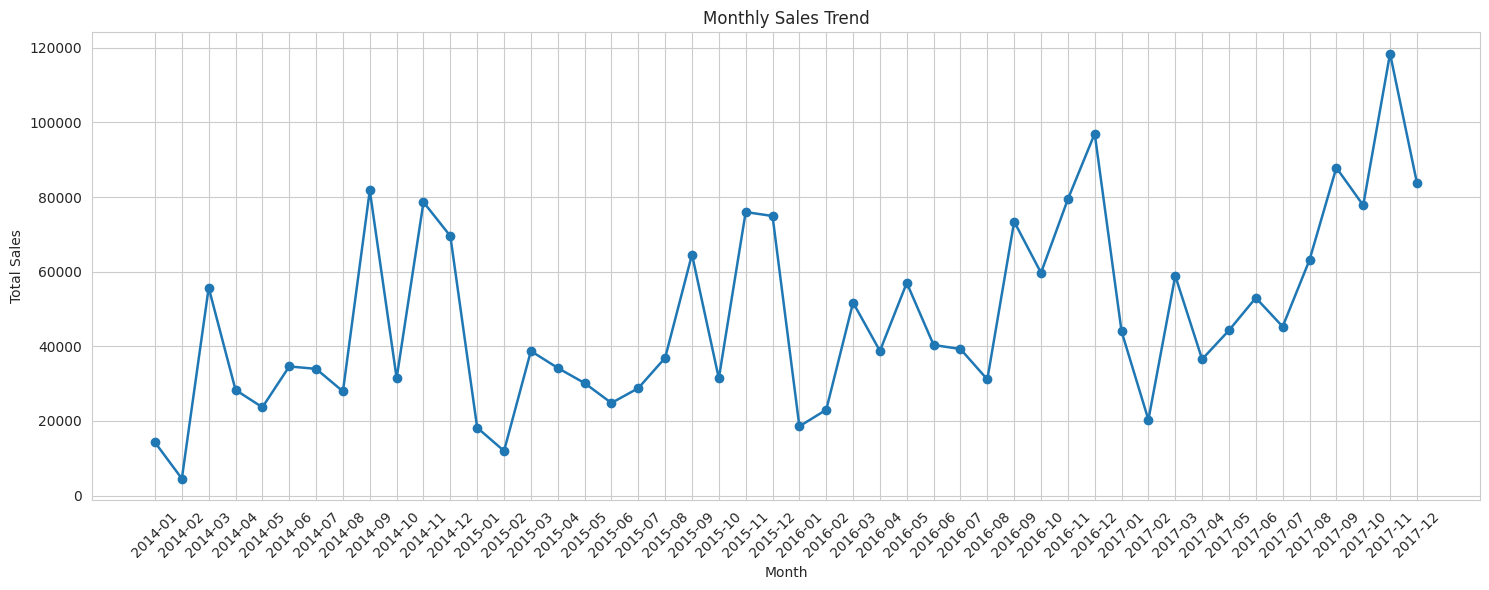

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linewidth=1.8
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#highest sales month
highest_month = monthly_sales.idxmax()
highest_month_sales = monthly_sales.max()

print("Highest Sales Month:", highest_month)
print("Sales:", round(highest_month_sales, 2))

#lowest sales month
lowest_month = monthly_sales.idxmin()
lowest_month_sales = monthly_sales.min()

print("Lowest Sales Month:", lowest_month)
print("Sales:", round(lowest_month_sales, 2))

Highest Sales Month: 2017-11
Sales: 118447.82
Lowest Sales Month: 2014-02
Sales: 4519.89


### Observation
The monthly sales trend shows noticeable fluctuations throughout the four-year period. Several periods experience higher sales peaks, while other months show relatively lower sales. The highest and lowest sales months identified from the analysis provide useful information about demand patterns and potential seasonal effects.

The business can use these patterns to plan inventory, staffing, promotions, and marketing activities around periods of expected higher or lower demand.

In [ ]:
#Quarterly performance
quarterly_sales_overall = (
    df.groupby("Quarter")["Sales"]
      .sum()
)

quarterly_sales_overall

,Sales
Quarter,
1,359681.5758
2,445509.6196
3,613932.1057
4,878077.5592


In [ ]:
df["Year-Quarter"] = (
    df["Order Date"].dt.to_period("Q")
)
df["Year-Quarter"].head()

,Year-Quarter
0,2016Q4
1,2016Q4
2,2016Q2
3,2015Q4
4,2015Q4


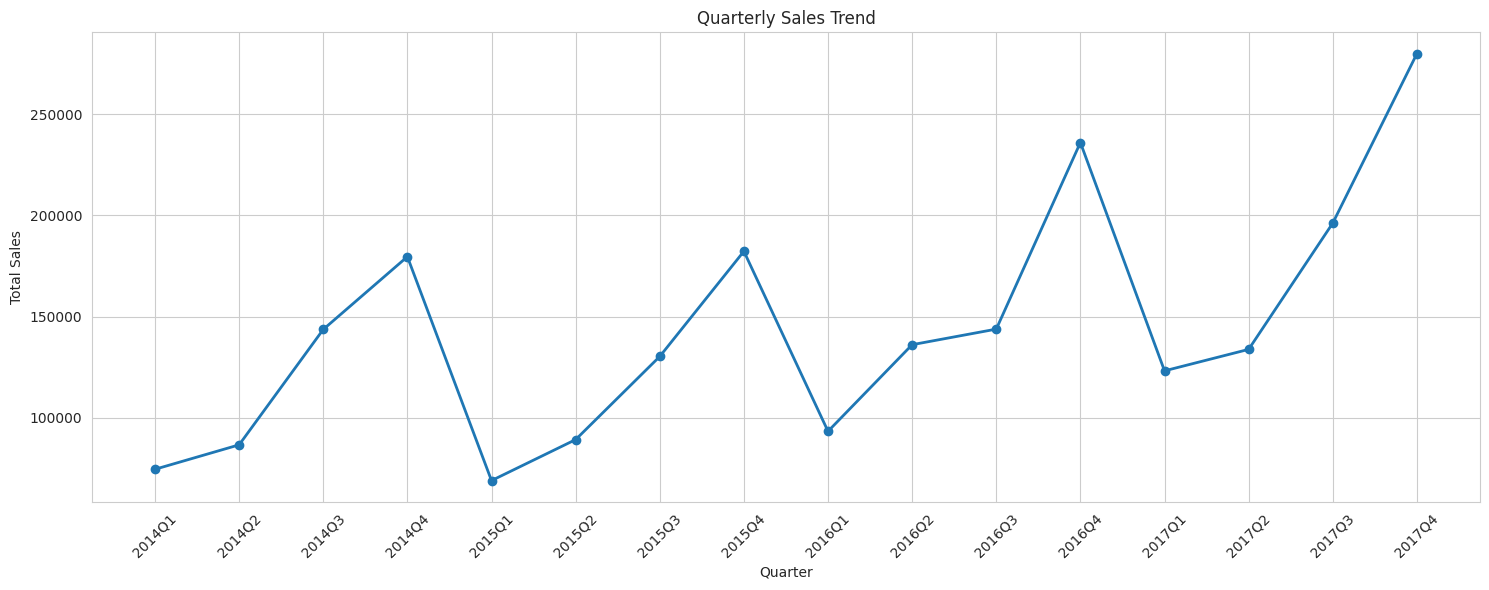

In [ ]:
quarterly_sales = (
    df.groupby("Year-Quarter")["Sales"]
      .sum()
)

plt.figure(figsize=(15, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
best_quarter = quarterly_sales.idxmax()
best_quarter_sales = quarterly_sales.max()

worst_quarter = quarterly_sales.idxmin()
worst_quarter_sales = quarterly_sales.min()

print("Best Quarter:", best_quarter)
print("Sales:", round(best_quarter_sales, 2))

print("\nWorst Quarter:", worst_quarter)
print("Sales:", round(worst_quarter_sales, 2))

Best Quarter: 2017Q4
Sales: 280054.07

Worst Quarter: 2015Q1
Sales: 68851.74


In [ ]:
quarterly_growth = quarterly_sales.pct_change() * 100

quarterly_growth.round(2)

,Sales
Year-Quarter,
2014Q1,NaN
2014Q2,16.24
2014Q3,65.98
2014Q4,25.06
2015Q1,-61.67
2015Q2,29.44
2015Q3,46.16
2015Q4,39.95
2016Q1,-48.85


In [ ]:
#top 10  best sales month
top_months = (
    monthly_sales
    .sort_values(ascending=False)
    .head(10)
)

top_months

,Sales
Year-Month,
2017-11,118447.8250
2016-12,96999.0430
2017-09,87866.6520
2017-12,83829.3188
2014-09,81777.3508
2016-11,79411.9658
2014-11,78628.7167
2017-10,77776.9232
2015-11,75972.5635


In [ ]:
#worst sales month
bottom_months = (
    monthly_sales
    .sort_values()
    .head(10)
)

bottom_months

,Sales
Year-Month,
2014-02,4519.8920
2015-02,11951.4110
2014-01,14236.8950
2015-01,18174.0756
2016-01,18542.4910
2017-02,20301.1334
2016-02,22978.8150
2014-05,23648.2870
2015-06,24797.2920


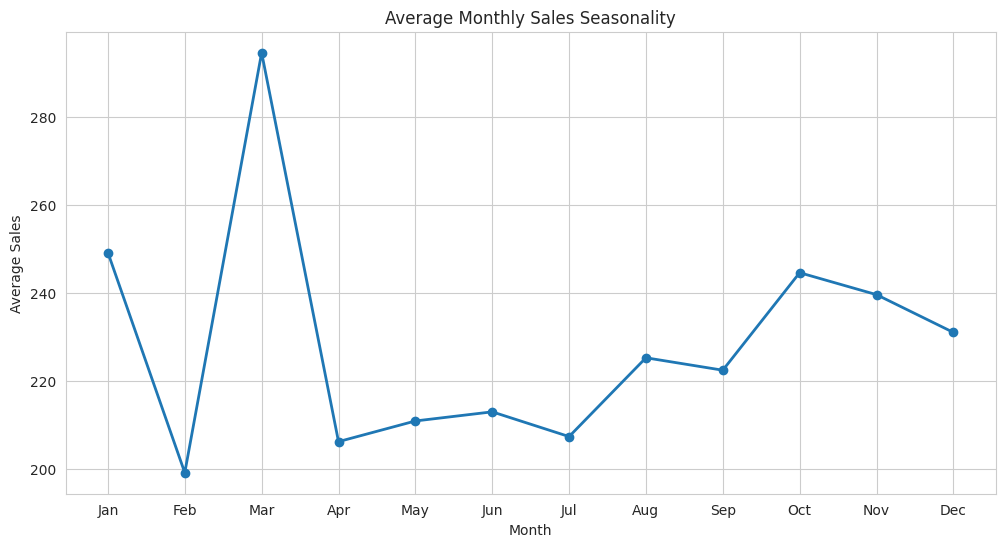

In [ ]:
#monthly seasonality analysis
monthly_seasonality = (
    df.groupby("Month")["Sales"]
      .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o",
    linewidth=2
)

plt.title("Average Monthly Sales Seasonality")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.xticks(
    range(1, 13),
    [
        "Jan", "Feb", "Mar", "Apr",
        "May", "Jun", "Jul", "Aug",
        "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.show()

Customer Analysis

In [ ]:
customer_columns = [
    "Customer ID",
    "Customer Name",
    "Segment",
    "Order ID",
    "Sales",
    "Quantity",
    "Profit"
]

df[customer_columns].head()

,Customer ID,Customer Name,Segment,Order ID,Sales,Quantity,Profit
0,CG-12520,Claire Gute,Consumer,CA-2016-152156,261.9600,2,41.9136
1,CG-12520,Claire Gute,Consumer,CA-2016-152156,731.9400,3,219.5820
2,DV-13045,Darrin Van Huff,Corporate,CA-2016-138688,14.6200,2,6.8714
3,SO-20335,Sean O'Donnell,Consumer,US-2015-108966,957.5775,5,-383.0310
4,SO-20335,Sean O'Donnell,Consumer,US-2015-108966,22.3680,2,2.5164


In [ ]:
unique_customers = df["Customer ID"].nunique()
print("Number of unique customers:", unique_customers)

Number of unique customers: 793


In [ ]:
#customer segment distribution
segment_counts = df["Segment"].value_counts()

segment_counts

,count
Segment,
Consumer,5191
Corporate,3020
Home Office,1783


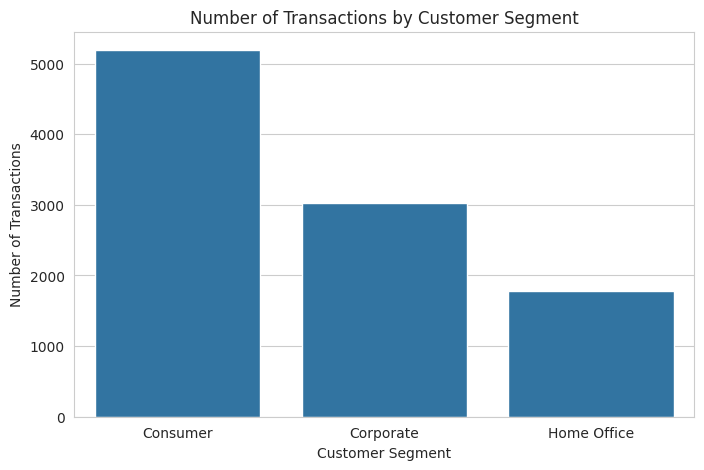

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title("Number of Transactions by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Transactions")

plt.show()

### Observation
The customer segment distribution shows that the dataset contains three major customer segments: Consumer, Corporate, and Home Office. The number of transactions varies across these segments, indicating differences in purchasing activity.

In [ ]:
#sales by customer segment
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

,Sales
Segment,
Consumer,1.161401e+06
Corporate,7.061464e+05
Home Office,4.296531e+05


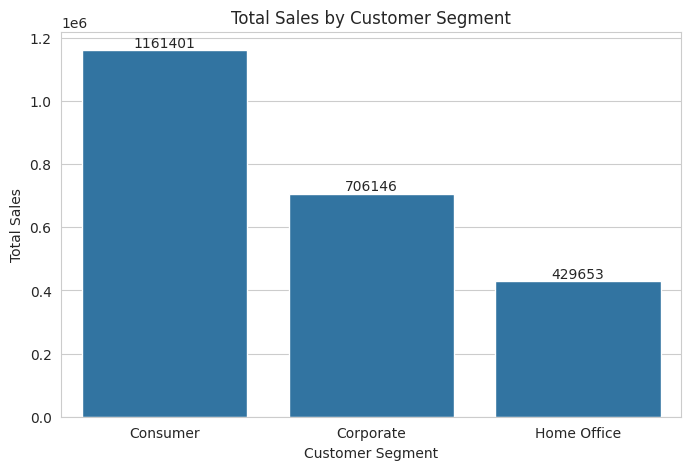

In [ ]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.show()

In [ ]:
#highest sales segment
best_sales_segment = segment_sales.idxmax()
best_sales_value = segment_sales.max()

print("Highest Sales Segment:", best_sales_segment)
print("Total Sales:", round(best_sales_value, 2))

Highest Sales Segment: Consumer
Total Sales: 1161401.34


Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


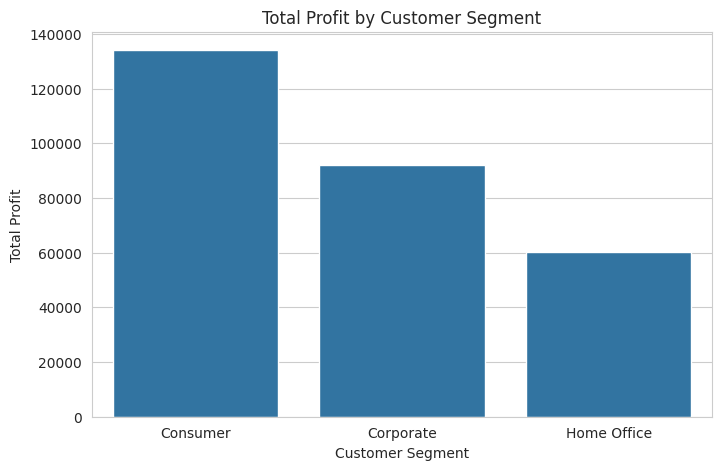

In [ ]:
#profit by customer segment
segment_profit = (
    df.groupby("Segment")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(segment_profit)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=segment_profit.index,
    y=segment_profit.values
)

plt.title("Total Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.show()

In [ ]:
#customer segment summary
segment_summary = df.groupby("Segment").agg(
    Transactions=("Order ID", "count"),
    Unique_Customers=("Customer ID", "nunique"),
    Total_Sales=("Sales", "sum"),
    Average_Sales=("Sales", "mean"),
    Total_Quantity=("Quantity", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Profit=("Profit", "mean")
)

segment_summary.round(2)

,Transactions,Unique_Customers,Total_Sales,Average_Sales,Total_Quantity,Total_Profit,Average_Profit
Segment,,,,,,,
Consumer,5191,409,1161401.34,223.73,19521,134119.21,25.84
Corporate,3020,236,706146.37,233.82,11608,91979.13,30.46
Home Office,1783,148,429653.15,240.97,6744,60298.68,33.82


In [ ]:
#profit margin by customer segment
segment_summary["Profit_Margin_%"] = (
    segment_summary["Total_Profit"] /
    segment_summary["Total_Sales"] * 100
)

segment_summary.round(2)

,Transactions,Unique_Customers,Total_Sales,Average_Sales,Total_Quantity,Total_Profit,Average_Profit,Profit_Margin_%
Segment,,,,,,,,
Consumer,5191,409,1161401.34,223.73,19521,134119.21,25.84,11.55
Corporate,3020,236,706146.37,233.82,11608,91979.13,30.46,13.03
Home Office,1783,148,429653.15,240.97,6744,60298.68,33.82,14.03


here we can say that 'Home Office'
segmnet is highest profit margin

In [ ]:
#Top 10 customer generating the highest total sales
customer_summary = df.groupby(
    ["Customer ID", "Customer Name", "Segment"]
).agg(
    Orders=("Order ID", "nunique"),
    Total_Sales=("Sales", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Total_Profit=("Profit", "sum")
).reset_index()

top_customers_sales = (
    customer_summary
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

top_customers_sales

,Customer ID,Customer Name,Segment,Orders,Total_Sales,Total_Quantity,Total_Profit
700,SM-20320,Sean Miller,Home Office,5,25043.050,50,-1980.7393
741,TC-20980,Tamara Chand,Corporate,5,19052.218,42,8981.3239
621,RB-19360,Raymond Buch,Consumer,6,15117.339,71,6976.0959
730,TA-21385,Tom Ashbrook,Home Office,4,14595.620,36,4703.7883
6,AB-10105,Adrian Barton,Consumer,10,14473.571,73,5444.8055
434,KL-16645,Ken Lonsdale,Consumer,12,14175.229,113,806.8550
669,SC-20095,Sanjit Chand,Consumer,9,14142.334,87,5757.4119
327,HL-15040,Hunter Lopez,Consumer,6,12873.298,50,5622.4292
683,SE-20110,Sanjit Engle,Consumer,11,12209.438,78,2650.6769
131,CC-12370,Christopher Conant,Consumer,5,12129.072,34,2177.0493


In [ ]:
#top 10 customers by profit
top_customers_profit = (
    customer_summary
    .sort_values("Total_Profit", ascending=False)
    .head(10)
)

top_customers_profit

,Customer ID,Customer Name,Segment,Orders,Total_Sales,Total_Quantity,Total_Profit
741,TC-20980,Tamara Chand,Corporate,5,19052.218,42,8981.3239
621,RB-19360,Raymond Buch,Consumer,6,15117.339,71,6976.0959
669,SC-20095,Sanjit Chand,Consumer,9,14142.334,87,5757.4119
327,HL-15040,Hunter Lopez,Consumer,6,12873.298,50,5622.4292
6,AB-10105,Adrian Barton,Consumer,10,14473.571,73,5444.8055
730,TA-21385,Tom Ashbrook,Home Office,4,14595.620,36,4703.7883
160,CM-12385,Christopher Martinez,Consumer,4,8954.020,34,3899.8904
424,KD-16495,Keith Dawkins,Corporate,12,8181.256,84,3038.6254
48,AR-10540,Andy Reiter,Consumer,6,6608.448,33,2884.6208
234,DR-12940,Daniel Raglin,Home Office,8,8350.868,57,2869.0760


In [ ]:
#customer segment region sales
segment_region_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Segment",
    columns="Region",
    aggfunc="sum"
)

segment_region_sales.round(2)

Region,Central,East,South,West
Segment,,,,
Consumer,252031.43,350908.17,195580.97,362880.77
Corporate,157995.81,200409.35,121885.93,225855.27
Home Office,91212.64,127463.73,74255.00,136721.78


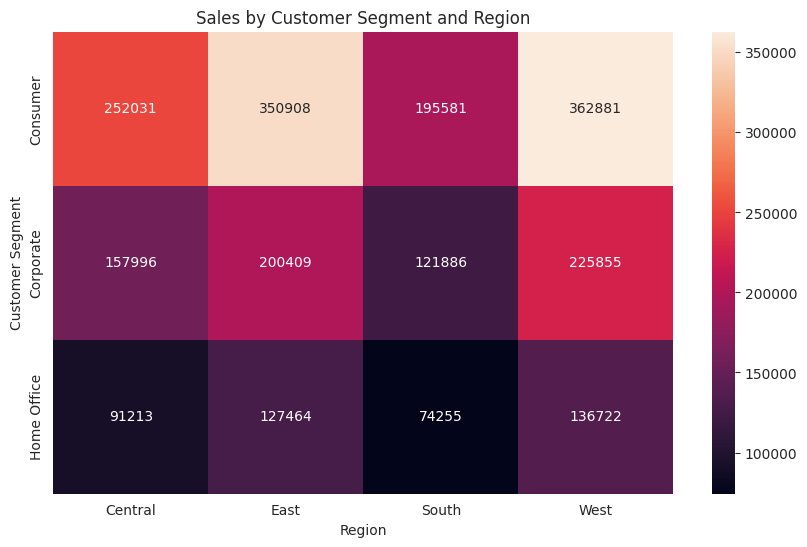

In [ ]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    segment_region_sales,
    annot=True,
    fmt=".0f"
)

plt.title("Sales by Customer Segment and Region")
plt.xlabel("Region")
plt.ylabel("Customer Segment")

plt.show()

by analyzing the heat map we can say that ,Consumer customers may dominate one region, while Corporate customers may be relatively stronger in another.That can help regional marketing strategies

## PRODUCT ANALYSIS

In [ ]:
#top 10 best selling products
top_products = (
    df.groupby("Product Name")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,Quantity
Product Name,
Staples,215
Staple envelope,170
Easy-staple paper,150
Staples in misc. colors,86
KI Adjustable-Height Table,74
Storex Dura Pro Binders,71
Avery Non-Stick Binders,71
GBC Premium Transparent Covers with Diagonal Lined Pattern,67
"Situations Contoured Folding Chairs, 4/Set",64


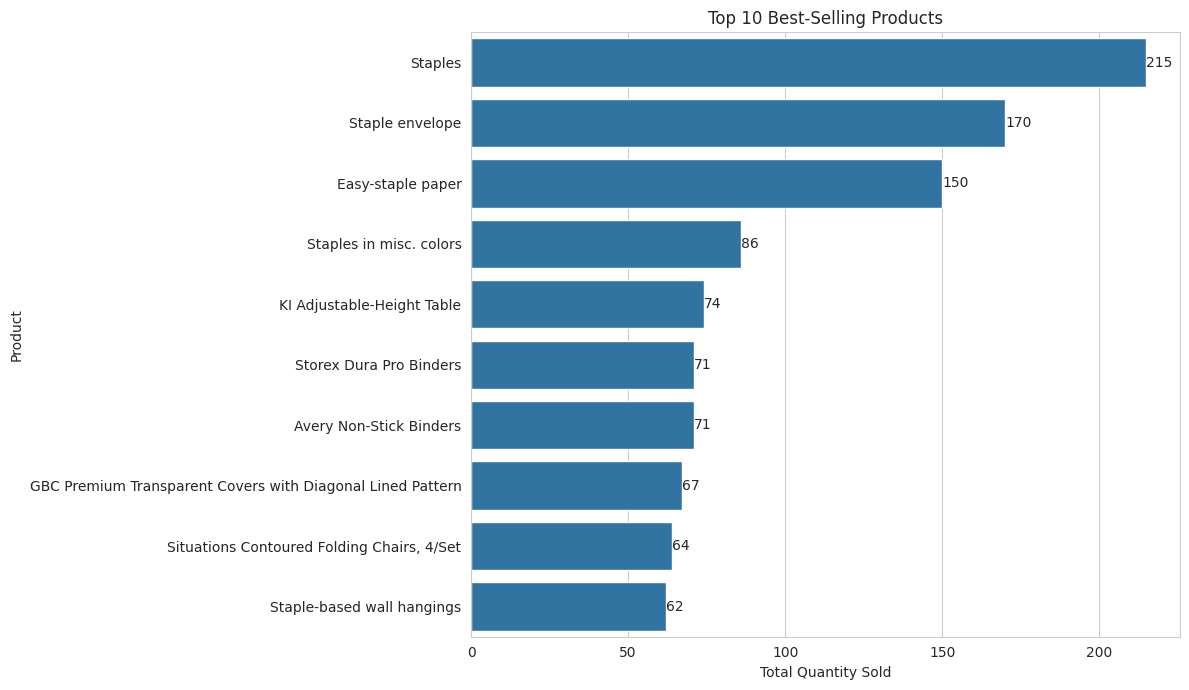

In [ ]:
plt.figure(figsize=(12, 7))

ax = sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## REVENUE BY CATEGORY

In [ ]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


In [ ]:
total_revenue = category_sales.sum()

category_revenue_percentage = (
    category_sales / total_revenue * 100
)

category_revenue_percentage.round(2)

,Sales
Category,
Technology,36.4
Furniture,32.3
Office Supplies,31.3


##CORRELATION ANALYSIS

In [ ]:
analysis_numeric_cols = [
    "Sales",
    "Quantity",
    "Discount",
    "Profit",
    "Shipping Days"
]
df[analysis_numeric_cols].head()

,Sales,Quantity,Discount,Profit,Shipping Days
0,261.9600,2,0.00,41.9136,3
1,731.9400,3,0.00,219.5820,3
2,14.6200,2,0.00,6.8714,4
3,957.5775,5,0.45,-383.0310,7
4,22.3680,2,0.20,2.5164,7


In [ ]:
correlation_matrix = df[analysis_numeric_cols].corr()

correlation_matrix.round(2)

,Sales,Quantity,Discount,Profit,Shipping Days
Sales,1.00,0.20,-0.03,0.48,-0.01
Quantity,0.20,1.00,0.01,0.07,0.02
Discount,-0.03,0.01,1.00,-0.22,0.00
Profit,0.48,0.07,-0.22,1.00,-0.00
Shipping Days,-0.01,0.02,0.00,-0.00,1.00


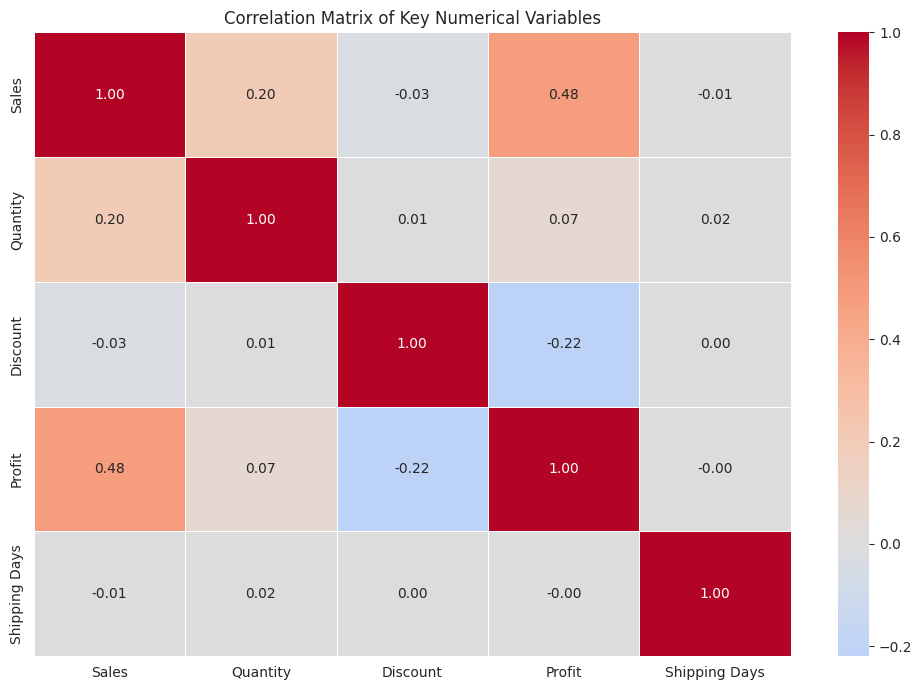

In [ ]:
#correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Key Numerical Variables")

plt.tight_layout()
plt.show()

after analysing the heatmap, it is clearlily showing that "Discount shows a negative correlation with profit, suggesting that higher discount levels are associated with lower profitability."

In [ ]:
#additional business visualizations
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)
region_profit = (
    df.groupby("Region")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

region_summary = pd.DataFrame({
    "Total Sales": region_sales,
    "Total Profit": region_profit
})

region_summary["Profit Margin (%)"] = (
    region_summary["Total Profit"] /
    region_summary["Total Sales"] * 100
)

region_summary.round(2)


,Total Sales,Total Profit,Profit Margin (%)
Region,,,
Central,501239.89,39706.36,7.92
East,678781.24,91522.78,13.48
South,391721.90,46749.43,11.93
West,725457.82,108418.45,14.94


BUSINESS INSIGHTS

In [ ]:
# 1- sales performance over time
best_sales_year = yearly_sales.idxmax()
best_sales_year_value = yearly_sales.max()

print("Best Sales Year:", best_sales_year)
print("Sales:", round(best_sales_year_value, 2))

yearly_growth = yearly_sales.pct_change() * 100

yearly_growth.round(2)

Best Sales Year: 2017
Sales: 733215.26


,Sales
Year,
2014,NaN
2015,-2.83
2016,29.47
2017,20.36


Here we see that the best sales year is 2017, with sales of 733215, and in 2016, a strong sales growth occurred

In [ ]:
# 2- most valuable customer segemnt
best_customer_segment = (
    segment_summary["Total_Sales"].idxmax()
)
best_profit_segment = (
    segment_summary["Total_Profit"].idxmax()
)
best_margin_segment = (
    segment_summary["Profit_Margin_%"].idxmax()
)

print(
    "Highest Sales Customer Segment:",
    best_customer_segment
)
print(
    "Highest Profit Customer Segment:",
    best_profit_segment
)
print(
    "Highest Profit Margin Segment:",
    best_margin_segment
)

Highest Sales Customer Segment: Consumer
Highest Profit Customer Segment: Consumer
Highest Profit Margin Segment: Home Office


In [ ]:
# 3- top selling products
top_product_name = top_products.index[0]
top_product_quantity = top_products.iloc[0]

print("Best-Selling Product:", top_product_name)
print("Quantity Sold:", top_product_quantity)

Best-Selling Product: Staples
Quantity Sold: 215


The product analysis identifies the top 10 products based on total quantity sold. These high-volume products indicate strong customer demand and may require careful inventory planning to maintain availability.

The best-selling product represents the highest unit demand in the dataset. However, sales volume should not be treated as a direct measure of profitability because product prices, discounts, and costs can vary.

In [ ]:
# 4- Regional performance
best_region_sales = region_summary["Total Sales"].idxmax()
best_region_profit = region_summary["Total Profit"].idxmax()
best_region_margin = (region_summary["Profit Margin (%)"].idxmax())

print(
    "Highest Sales Region:",best_region_sales,"\n""Highest Profit Region:",best_region_profit,"\n""Highest Profit Margin Region:",best_region_margin

)

Highest Sales Region: West 
Highest Profit Region: West 
Highest Profit Margin Region: West


"West is the strongest region by sales and total profit,as well as  stronger profitability efficiency."

In [ ]:
# SUMMARY
business_insights = pd.DataFrame({
    "Business Area": [
        "Sales",
        "Customer Segment",
        "Best-Selling Product",
        "Region"

    ],

    "Key Metric": [
        "Highest Sales Year",
        "Highest Sales Segment",
        "Highest Quantity Sold",
        "Highest Sales Region"

    ],

    "Result": [
        str(best_sales_year),
        best_customer_segment,
        top_product_name,
        best_region_sales,

    ]
})

business_insights

,Business Area,Key Metric,Result
0,Sales,Highest Sales Year,2017
1,Customer Segment,Highest Sales Segment,Consumer
2,Best-Selling Product,Highest Quantity Sold,Staples
3,Region,Highest Sales Region,West


##BUSINESS RECOMMENDATIONS

In [ ]:
recommendations = pd.DataFrame({
    "Priority": [
        "High",
        "High",
        "High",
        "Medium",
        "High",
        "Medium",
        "Medium",
        "High"
    ],

    "Area": [
        "Category Performance",
        "Discount Strategy",
        "Inventory",
        "Regional Strategy",
        "Profitability",
        "Customer Segmentation",
        "Customer Retention",
        "Demand Planning"
    ],

    "Recommendation": [
        "Focus inventory and marketing on strong revenue and profit categories.",
        "Use controlled and targeted discounting to protect margins.",
        "Prioritize inventory availability for high-demand products.",
        "Develop region-specific strategies based on sales and profitability.",
        "Monitor sales, profit, and profit margin together.",
        "Develop strategies based on customer segment performance.",
        "Focus retention efforts on high-value customers.",
        "Use historical demand patterns to improve inventory planning."
    ],

    "Expected Impact": [
        "Sustainable category growth",
        "Improved profit margins",
        "Reduced stock-outs",
        "Improved regional performance",
        "Better profitability",
        "Improved marketing efficiency",
        "Higher customer retention",
        "Better inventory efficiency"
    ]
})

recommendations

,Priority,Area,Recommendation,Expected Impact
0,High,Category Performance,Focus inventory and marketing on strong revenu...,Sustainable category growth
1,High,Discount Strategy,Use controlled and targeted discounting to pro...,Improved profit margins
2,High,Inventory,Prioritize inventory availability for high-dem...,Reduced stock-outs
3,Medium,Regional Strategy,Develop region-specific strategies based on sa...,Improved regional performance
4,High,Profitability,"Monitor sales, profit, and profit margin toget...",Better profitability
5,Medium,Customer Segmentation,Develop strategies based on customer segment p...,Improved marketing efficiency
6,Medium,Customer Retention,Focus retention efforts on high-value customers.,Higher customer retention
7,High,Demand Planning,Use historical demand patterns to improve inve...,Better inventory efficiency



Based on the analysis, the business should prioritize the following actions:

1. Focus inventory and marketing resources on high-performing categories.
2. Review discounting practices and establish controlled discount thresholds where appropriate.
3. Maintain adequate inventory for high-demand products.
4. Develop region-specific strategies based on sales and profitability.
5. Monitor profit and profit margin alongside revenue.
6. Use customer segmentation to improve targeting and marketing efficiency.
7. Develop retention strategies for high-value customers.
8. Use historical demand and sales patterns to improve inventory planning.

These recommendations are designed to support sustainable revenue growth, stronger profitability, better inventory management, and more data-driven decision-making.

###CONCLUSION

The Superstore dataset was analyzed to understand sales performance, customer behavior, product demand, regional performance, profitability, and the relationship between key business variables.

The analysis began with data inspection and cleaning to ensure that the dataset was suitable for analysis. Descriptive statistics were then used to understand the overall distribution of the numerical variables.

Time-series analysis was performed to identify sales trends over time, while customer and product analyses were used to identify important customer segments and high-demand products.

Regional and category-level analyses provided insights into differences in revenue and profitability across geographic and product dimensions. Correlation analysis was also performed to understand relationships between variables such as Sales, Quantity, Discount, Profit, and Shipping Days.

The findings were then converted into actionable business recommendations related to inventory planning, discount management, customer segmentation, regional strategies, category performance, and profitability management.

Overall, the analysis demonstrates how data analytics can help transform raw transactional data into meaningful business insights and support more informed decision-making.

#Key Findings
The major findings from the analysis are:

1. Sales performance varies across different time periods, with certain years and months contributing significantly more to overall revenue.

2. Customer segments differ in their contribution to sales and profitability, showing that revenue and profit should be evaluated separately.

3. A small group of products accounts for a significant amount of unit sales, making these products important for inventory planning.

4. Revenue contribution differs across Furniture, Office Supplies, and Technology categories.

5. Regional performance varies across sales, profit, and profit margin, indicating opportunities for region-specific strategies.

6. The correlation analysis provides useful information about the relationships between Sales, Quantity, Discount, Profit, and Shipping Days.

7. Discounting and profitability should be monitored together to ensure that sales growth does not come at the expense of excessive margin reduction.

In [ ]:
#Final KPI table
final_kpis = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Total Profit",
        "Total Orders",
        "Total Customers",
        "Highest Sales Year",
        "Highest Sales Region",
        "Highest Profit Region"
    ],

    "Value": [
        round(df["Sales"].sum(), 2),
        round(df["Profit"].sum(), 2),
        df["Order ID"].nunique(),
        df["Customer ID"].nunique(),
        best_sales_year,
        best_region_sales,
        best_region_profit
    ]
})

final_kpis

,KPI,Value
0,Total Sales,2297200.86
1,Total Profit,286397.02
2,Total Orders,5009
3,Total Customers,793
4,Highest Sales Year,2017
5,Highest Sales Region,West
6,Highest Profit Region,West


##Final conclusion
This project demonstrates an end-to-end data analytics workflow using the Superstore dataset. The analysis transformed raw transactional data into meaningful information through data cleaning, exploratory analysis, statistical analysis, visualization, business insight generation, and recommendation development.

The analysis shows that evaluating business performance requires more than looking at total sales. Profitability, customer segments, product demand, regional performance, discounts, and trends must also be considered.

The resulting insights can support better decisions related to inventory management, pricing and discount strategies, customer targeting, regional planning, and sustainable business growth.

Overall, the project demonstrates how data analytics can bridge the gap between raw business data and actionable decision-making.